In [42]:
import pandas as pd
import seaborn as sns
import yaml
import matplotlib.pyplot as plt

In [10]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

In [11]:
demo_df = pd.read_csv(config["input_data"]["file1"])
demo_df


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


In [12]:
demo_df.shape

(70609, 9)

In [13]:
demo_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.8 MB


In [14]:
sorted_balance = demo_df.sort_values(by='bal')
sorted_balance

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
57006,9020160,9.0,108.0,63.0,F,1.0,13789.42,2.0,2.0
55126,989035,15.0,184.0,41.0,M,2.0,13791.34,1.0,1.0
61826,3280109,15.0,185.0,59.0,F,2.0,13791.80,7.0,7.0
66292,9862353,17.0,205.0,59.0,M,2.0,13792.98,7.0,7.0
53141,2210130,8.0,105.0,18.0,M,2.0,13793.69,3.0,3.0
...,...,...,...,...,...,...,...,...,...
46076,8611797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47189,5144725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49846,1037867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63701,1618749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


There are a some rows without any data except a client ID. They are unusable so let's drop them

In [15]:
demo_df_cleaned = demo_df.dropna(how='all', subset=demo_df.columns.difference(['client_id']))
demo_df_cleaned = demo_df_cleaned.reset_index(drop=True)
demo_df_cleaned

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70590,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70591,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70592,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70593,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


In [16]:
demo_df_cleaned.to_csv('demo_df_cleaned.csv', index=False)

In [17]:
demo_df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 70595 entries, 0 to 70594
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70595 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.8 MB


Only 1 NaN value left in age column. We will ignore this Nan value since it will not distort our research

In [18]:
#check how many time clients logged on in the last 6 months
sorted_unique_values = sorted(demo_df_cleaned['logons_6_mnth'].unique())

print(sorted_unique_values)


[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]


In [19]:
# Create a Boolean series to filter users with 9 logons
top_users_filter = demo_df_cleaned['logons_6_mnth'] == 9

# Filter the DataFrame using the Boolean series
top_users = demo_df_cleaned[top_users_filter]

# Display the first few rows of the filtered result
display(top_users)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
9,8198645,15.0,189.0,54.5,F,2.0,382303.83,6.0,9.0
11,2537139,8.0,99.0,51.5,U,2.0,135940.68,6.0,9.0
...,...,...,...,...,...,...,...,...,...
50473,3823121,14.0,178.0,68.5,F,2.0,32666.22,6.0,9.0
50477,6751438,8.0,98.0,49.5,U,2.0,416988.75,6.0,9.0
50481,9932367,23.0,280.0,57.0,F,2.0,94466.55,6.0,9.0
50483,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0


There are 12.350 clients how logged on 9 times in the last 6 months

In [20]:
#sort clients by ages
top_users_age = top_users.sort_values(by= 'clnt_age')
display(top_users_age)


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
2716,6516140,5.0,66.0,17.5,U,2.0,74939.63,6.0,9.0
23120,8927242,3.0,39.0,17.5,U,3.0,56048.17,6.0,9.0
22034,8365990,3.0,40.0,17.5,U,2.0,66353.04,6.0,9.0
2283,5269888,20.0,243.0,17.5,F,2.0,39631.34,6.0,9.0
3195,5747508,5.0,66.0,17.5,U,2.0,42447.47,6.0,9.0
...,...,...,...,...,...,...,...,...,...
45342,1359640,12.0,148.0,92.0,M,2.0,596701.54,6.0,9.0
33047,6533602,29.0,348.0,93.0,F,2.0,362103.22,6.0,9.0
42551,3112487,7.0,91.0,93.0,U,2.0,30461.89,6.0,9.0
35861,5890936,28.0,347.0,93.5,M,3.0,1364856.21,6.0,9.0


In [21]:
# Group by 'clnt_age' and count the number of occurrences
age_distribution = top_users_age.groupby('clnt_age').size().reset_index(name='client_count')

# Sort the resulting DataFrame by 'clnt_age' for readability
age_distribution_sorted = age_distribution.sort_values(by='clnt_age')

# Display the DataFrame showing the number of clients of each age
display(age_distribution_sorted)

,clnt_age,client_count
0,17.5,5
1,18.0,11
2,18.5,20
3,19.0,11
4,19.5,24
...,...,...
145,91.5,1
146,92.0,1
147,93.0,2
148,93.5,1


In [22]:
# Calculate the mean age
mean_age = top_users_age['clnt_age'].mean()
print(f"Mean age: {mean_age}")

# Calculate the median age
median_age = top_users_age['clnt_age'].median()
print(f"Median age: {median_age}")

# Calculate the mode(s) of the ages using dropna() to ensure accuracy
mode_age = top_users_age['clnt_age'].dropna().mode()
print(f"Mode age(s): {mode_age.tolist()}")

percentiles = top_users_age['clnt_age'].quantile([0.25, 0.50, 0.75])
print(percentiles)

Mean age: 47.491133603238865
Median age: 48.0
Mode age(s): [27.5]
0.25    32.5
0.50    48.0
0.75    61.0
Name: clnt_age, dtype: float64


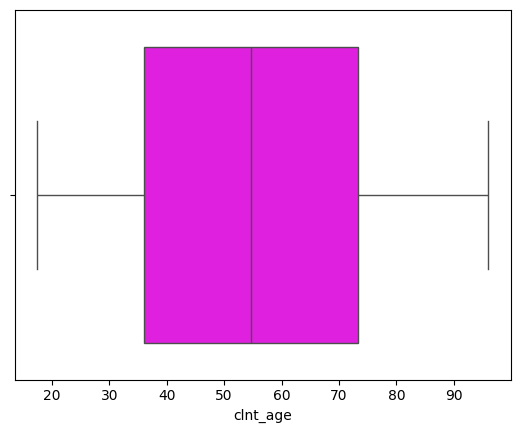

In [25]:
sns.boxplot(x = age_distribution['clnt_age'], color="fuchsia");

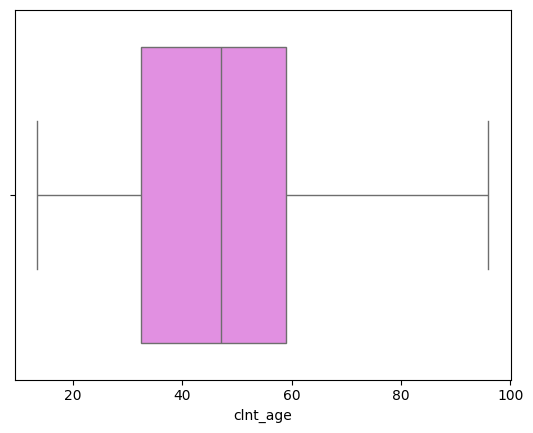

In [31]:
sns.boxplot(x = demo_df_cleaned['clnt_age'], color="violet");

In [34]:
demo_df_cleaned.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth'],
      dtype='str')

C:\Users\Ready2Use\AppData\Local\Temp\ipykernel_25904\3490666458.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=demo_df_cleaned, x='age_group', y='logons_6_mnth', palette="bright")


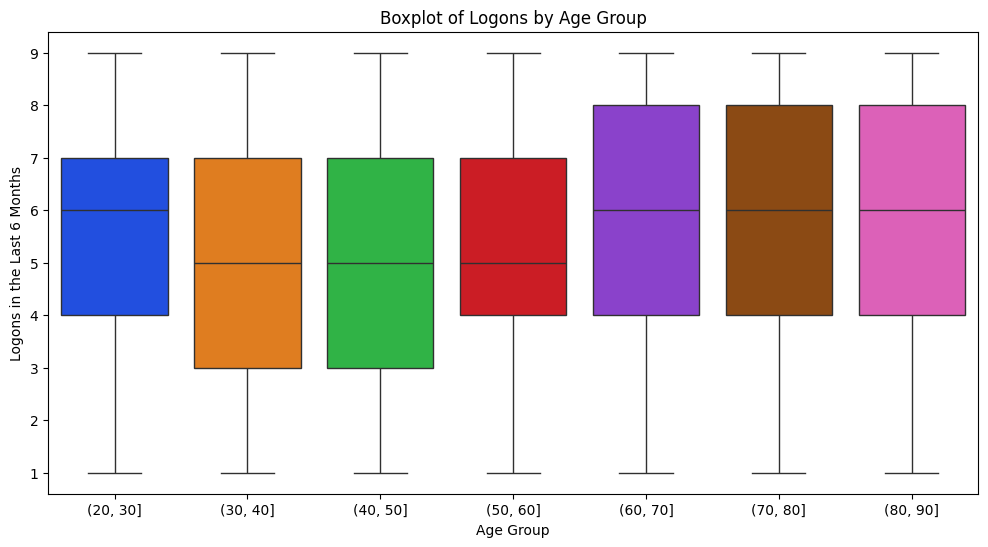

In [50]:
#Categorize ages into bins
demo_df_cleaned['age_group'] = pd.cut(demo_df_cleaned['clnt_age'], bins=range(20, 100, 10))

# Create the boxplot with age groups
plt.figure(figsize=(12, 6))
sns.boxplot(data=demo_df_cleaned, x='age_group', y='logons_6_mnth', palette="bright")

# Add labels and title
plt.title('Boxplot of Logons by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Logons in the Last 6 Months')

# Display the plot
plt.show()

C:\Users\Ready2Use\AppData\Local\Temp\ipykernel_25904\321622474.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=demo_df_cleaned, x='age_group', y='calls_6_mnth', palette="pastel")


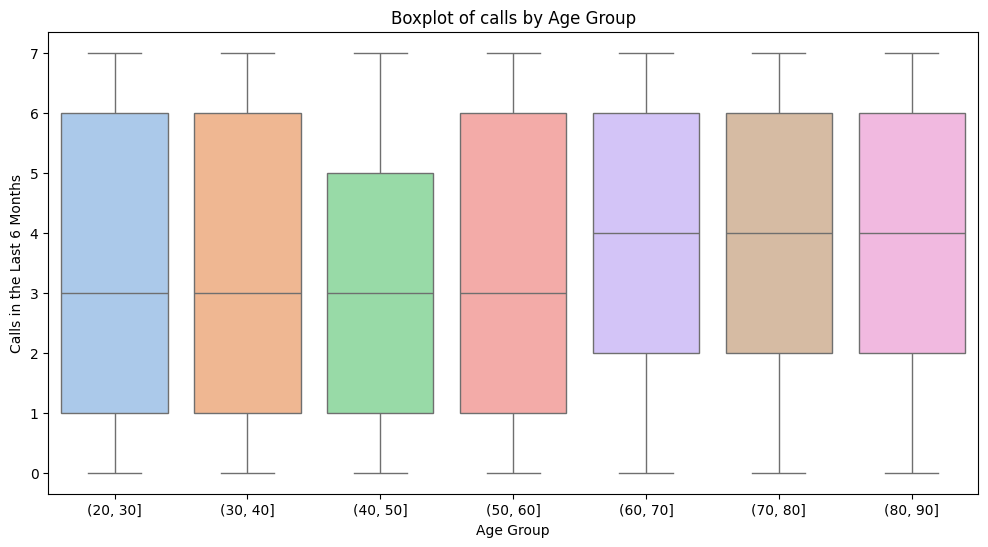

In [51]:
#Categorize ages into bins
demo_df_cleaned['age_group'] = pd.cut(demo_df_cleaned['clnt_age'], bins=range(20, 100, 10))

# Create the boxplot with age groups
plt.figure(figsize=(12, 6))
sns.boxplot(data=demo_df_cleaned, x='age_group', y='calls_6_mnth', palette="pastel")

# Add labels and title
plt.title('Boxplot of calls by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Calls in the Last 6 Months')

# Display the plot
plt.show()

Clients between  are using the online log in between 48 and 61 most.